In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

### 1. 讀入資料集

In [ ]:
!wget --no-check-certificate \
    https://github.com/yenlung/Python-AI-Book/raw/main/dataset/Cooper_img.zip \
    -O /content/Cooper.zip

--2024-08-09 00:27:45--  https://github.com/yenlung/Python-AI-Book/raw/main/dataset/Cooper_img.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/yenlung/Python-AI-Book/main/dataset/Cooper_img.zip [following]
--2024-08-09 00:27:45--  https://raw.githubusercontent.com/yenlung/Python-AI-Book/main/dataset/Cooper_img.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1023448 (999K) [application/zip]
Saving to: ‘/content/Cooper.zip’

/content/Cooper.zip 100%[===================>] 999.46K  --.-KB/s    in 0.02s   

2024-08-09 00:27:45 (41.4 MB/s) - ‘/content/Cooper.zip’ saved [1023448/1023448]



In [ ]:
import os
import zipfile

local_zip = '/content/Cooper.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
base_dir = '/content/'
cooper_dir = 'Cooper/'
thedir = base_dir + cooper_dir

In [ ]:
cooper = [f"{cooper_dir}/cooper0{i}.jpg" for i in range(1, 7)]

### 2. 讀入一隻 Cooper 試試

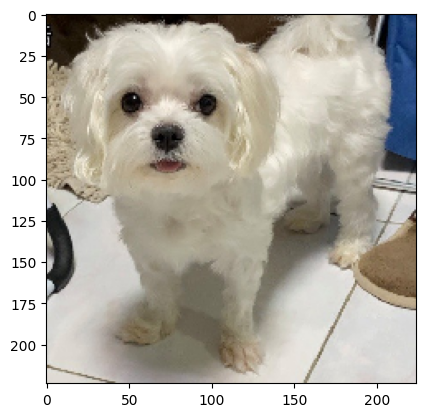

In [ ]:
img = load_img(cooper[2], target_size = (224, 224))
plt.imshow(img)

In [ ]:
x = img_to_array(img)

### 3. 讀入 ResNet50 及 labels

In [ ]:
with open('imagenet-classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]

In [ ]:
labels[:10]

['tench 鯉魚類淡水魚',
 'goldfish 金魚',
 'great white shark 大白鯊',
 'tiger shark 虎鯊',
 'hammerhead 鎚頭鯊',
 'electric ray 電魟',
 'stingray 魟魚',
 'cock 公雞',
 'hen 母雞',
 'ostrich 鴕鳥']

In [ ]:
model = ResNet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
x = img_to_array(img).reshape(1, 224, 224, 3)

In [ ]:
inp = preprocess_input(x)

In [ ]:
outp = model.predict([inp])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [ ]:
y_pred = np.argmax(model.predict(inp), axis=-1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
print(f"ResNet 覺得是 {labels[y_pred]}")

ResNet 覺得是 Maltese dog 馬爾濟斯犬


In [ ]:
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.applications import ResNet50
import io
import matplotlib.pyplot as plt

# Load the ResNet50 model pre-trained on ImageNet
resnet = ResNet50(weights='imagenet')

def classify_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).resize((224, 224))
    inp = np.array(image)
    inp = np.expand_dims(inp, axis=0)
    inp = preprocess_input(inp)

    # Perform prediction
    prediction = resnet.predict(inp)

    # Decode predictions to get human-readable labels
    decoded_predictions = decode_predictions(prediction, top=3)[0]

    # Format the results
    results = {label: float(confidence) for (_, label, confidence) in decoded_predictions}
    return results

# Upload image (for example, in a Jupyter notebook or Colab, this might be done with files.upload())
# Here, we assume `uploaded` is a dictionary with the filename as the key and image data as the value.

# Example upload handling (you should replace this with actual file handling logic)
from google.colab import files
uploaded = files.upload()

results = {}

for filename in uploaded.keys():
    # Open the uploaded image file
    image = Image.open(io.BytesIO(uploaded[filename]))

    # Display the image
    plt.imshow(image)
    plt.title('Uploaded Image')
    plt.axis('off')
    plt.show()

    # Save the image to a temporary file and get the file path
    temp_image_path = '/tmp/' + filename
    image.save(temp_image_path)

    # Perform classification
    results = classify_image(temp_image_path)

# Print results
print("Model's predictions:")
for label, confidence in results.items():
    print(f"{label}: {confidence:.4f}")


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
